# 信用违约预测 — Boosting 家族 5 模型演进实战

**任务**：根据借款人信用特征预测其未来两年内严重逾期（违约）的概率（二分类）
**核心目标**：在**同一份数据**上横向对比 **AdaBoost → GBDT → XGBoost → LightGBM → CatBoost** 五代 Boosting 模型，理解 Boosting 思想的演进脉络。

---

## 为什么用 GMSC？
- **15 万行**训练数据 → 能体现 XGBoost/LightGBM/CatBoost 的速度与工程优势
- **类别不平衡**（违约率仅 6.7%）→ 演示各模型的不平衡处理
- **20% 收入缺失 + 极端离群值** → 树模型原生处理缺失值的能力展示

## 建模步骤
1. 环境配置
2. 数据加载与概览
3. EDA（不平衡分析 + 缺失值）
4. 数据清洗
5. Boosting 家族 5 模型建模
6. 模型评估（AUC / KS / 混淆矩阵 / ROC）
7. 特征重要性对比
8. 预测并生成提交文件

## Boosting 家族 5 模型演进
| 模型 | 核心思想 | 相对前代的改进 |
|------|----------|----------------|
| AdaBoost | 自适应提升样本权重 | Boosting 鼻祖 |
| GBDT | 拟合损失函数负梯度 | 从权重转向梯度 |
| XGBoost | 正则化 + 二阶泰勒展开 | 防过拟合 + 更快更准 |
| LightGBM | 直方图 + GOSS + EFB + Leaf-wise | 大幅提速、降内存 |
| CatBoost | 有序目标统计 + 对称树 | 原生类别特征 + 防目标泄漏 |


## 1. 环境配置


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_score, recall_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("环境配置完成")
print(f"当前工作目录: {os.getcwd()}")


环境配置完成
当前工作目录: e:\BaiduNetdiskDownload\Study_files\学习考证\Agent_Exercise\Kaggle_Competitions\Machine_learning\XGBoost_LightGBM_CatBoost


In [2]:
# 兼容两种启动方式：
# 1) 在 XGBoost_LightGBM_CatBoost 目录启动 Jupyter -> GMSC-data
# 2) 在 Machine_learning 根目录启动 Jupyter -> XGBoost_LightGBM_CatBoost/GMSC-data
DATA_DIR = "GMSC-data" if os.path.exists("GMSC-data") else os.path.join("XGBoost_LightGBM_CatBoost", "GMSC-data")
assert os.path.exists(DATA_DIR), f"数据目录不存在: {DATA_DIR}"
print("数据文件:", sorted(os.listdir(DATA_DIR)))


数据文件: ['Data Dictionary.xls', 'cs-test.csv', 'cs-training.csv', 'sampleEntry.csv']


## 2. 数据加载与概览


In [3]:
# 与 GMSC 逻辑回归项目保持同一套读取方式（index_col=0）
train = pd.read_csv(os.path.join(DATA_DIR, "cs-training.csv"), index_col=0)
test = pd.read_csv(os.path.join(DATA_DIR, "cs-test.csv"), index_col=0)
sample = pd.read_csv(os.path.join(DATA_DIR, "sampleEntry.csv"))

print(f"训练集形状: {train.shape}")
print(f"测试集形状: {test.shape}")
print(f"提交样例形状: {sample.shape}")

target_col = "SeriousDlqin2yrs"
print(f"违约率: {train[target_col].mean():.2%}")
train.head()


训练集形状: (150000, 11)
测试集形状: (101503, 11)
提交样例形状: (101503, 2)
违约率: 6.68%


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


In [4]:
train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

## 3. EDA（不平衡分析 + 缺失值）


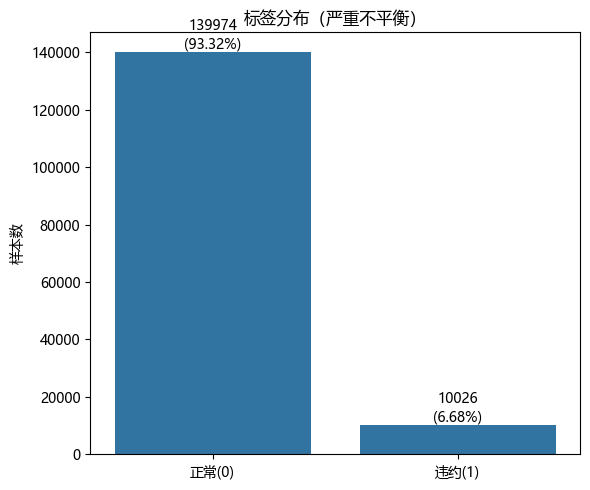

In [5]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
counts = train[target_col].value_counts().sort_index()
pcts = (counts / len(train) * 100).round(2)

plt.figure(figsize=(6, 5))
sns.barplot(x=["正常(0)", "违约(1)"], y=counts.values)
plt.title("标签分布（严重不平衡）")
plt.ylabel("样本数")
for i, (c, p) in enumerate(zip(counts.values, pcts.values)):
    plt.text(i, c, f"{c}\n({p}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()


In [6]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({"缺失数量": missing, "缺失比例%": missing_pct})


,缺失数量,缺失比例%
MonthlyIncome,29731,19.8200
NumberOfDependents,3924,2.6200


## 4. 数据清洗

统计量只从训练集计算，防止数据泄漏：
- 缺失值：`MonthlyIncome` / `NumberOfDependents` 用训练集中位数填充
- 异常值：对 5 个极端右偏特征做 99 分位 Winsorize 剪裁
- 年龄：约束到 18–100


In [7]:
FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]

monthly_median = train["MonthlyIncome"].median()
dependents_median = train["NumberOfDependents"].median()
cap_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]
caps = {c: train[c].quantile(0.99) for c in cap_cols}


def clean(df):
    df = df.copy()
    df["MonthlyIncome"] = df["MonthlyIncome"].fillna(monthly_median)
    df["NumberOfDependents"] = df["NumberOfDependents"].fillna(dependents_median)
    for c in caps:
        df[c] = df[c].clip(upper=caps[c])
    df["age"] = df["age"].clip(lower=18, upper=100)
    return df


train_clean = clean(train)
test_clean = clean(test)

X = train_clean[FEATURES]
y = train_clean[target_col]
X_test = test_clean[FEATURES]

print(f"训练特征: {X.shape}")
print(f"测试特征: {X_test.shape}")
print("清洗后缺失值:", int(X.isnull().sum().sum()))


训练特征: (150000, 10)
测试特征: (101503, 10)
清洗后缺失值: 0


## 5. Boosting 家族 5 模型建模

每个模型都配置了**不平衡处理**，用分层抽样保证类别比例一致：
- AdaBoost：弱学习器 `DecisionTreeClassifier(class_weight="balanced")`
- GBDT：sklearn 原生实现**不支持** `class_weight`，依靠分层抽样 + AUC 评估
- XGBoost：`scale_pos_weight` = 负样本/正样本
- LightGBM：`class_weight="balanced"`
- CatBoost：`auto_class_weights="Balanced"`


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}")
print(f"训练集违约率: {y_train.mean():.2%}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# ---- 5 个 Boosting 模型 ----
models = {
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        estimator=DecisionTreeClassifier(max_depth=1, class_weight="balanced", random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
    ),
    "GBDT": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=3,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        scale_pos_weight=scale_pos_weight, n_jobs=-1, random_state=RANDOM_STATE,
        eval_metric="auc",
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=31,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
        verbose=-1,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=4,
        auto_class_weights="Balanced", verbose=0, random_seed=RANDOM_STATE,
        allow_writing_files=False,
    ),
}


训练集: (120000, 10), 验证集: (30000, 10)
训练集违约率: 6.68%
scale_pos_weight: 13.96


In [9]:
# ---- 训练并评估（单次留出验证） ----
results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_val_proba = clf.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, y_val_proba)
    results[name] = {"AUC": auc_val, "模型": clf}
    print(f"{name:10s} 验证集 AUC={auc_val:.4f}")


AdaBoost   验证集 AUC=0.7808
GBDT       验证集 AUC=0.8653
XGBoost    验证集 AUC=0.8687
LightGBM   验证集 AUC=0.8678
CatBoost   验证集 AUC=0.8685


In [10]:
# ---- 5 折分层交叉验证 AUC（更稳健） ----
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, clf in models.items():
    cv_auc = cross_val_score(clf, X, y, cv=skf, scoring="roc_auc")
    cv_results[name] = cv_auc.mean()
    print(f"{name:10s} 5折CV-AUC={cv_auc.mean():.4f}  各折={np.round(cv_auc, 4)}")


AdaBoost   5折CV-AUC=0.7851  各折=[0.7803 0.7816 0.7946 0.7821 0.7868]
GBDT       5折CV-AUC=0.8620  各折=[0.8606 0.8611 0.8667 0.8561 0.8654]
XGBoost    5折CV-AUC=0.8656  各折=[0.8641 0.865  0.8701 0.86   0.8686]
LightGBM   5折CV-AUC=0.8649  各折=[0.8633 0.8652 0.8696 0.8585 0.8681]
CatBoost   5折CV-AUC=0.8647  各折=[0.8628 0.8648 0.8695 0.859  0.8672]


In [11]:
# ---- 对比表 ----
comparison = pd.DataFrame(
    {
        "验证集AUC": [results[k]["AUC"] for k in models],
        "5折CV-AUC": [cv_results[k] for k in models],
    },
    index=models.keys(),
).round(4).sort_values("5折CV-AUC", ascending=False)
comparison


,验证集AUC,5折CV-AUC
XGBoost,0.8687,0.8656
LightGBM,0.8678,0.8649
CatBoost,0.8685,0.8647
GBDT,0.8653,0.8620
AdaBoost,0.7808,0.7851


## 6. 模型评估与对比


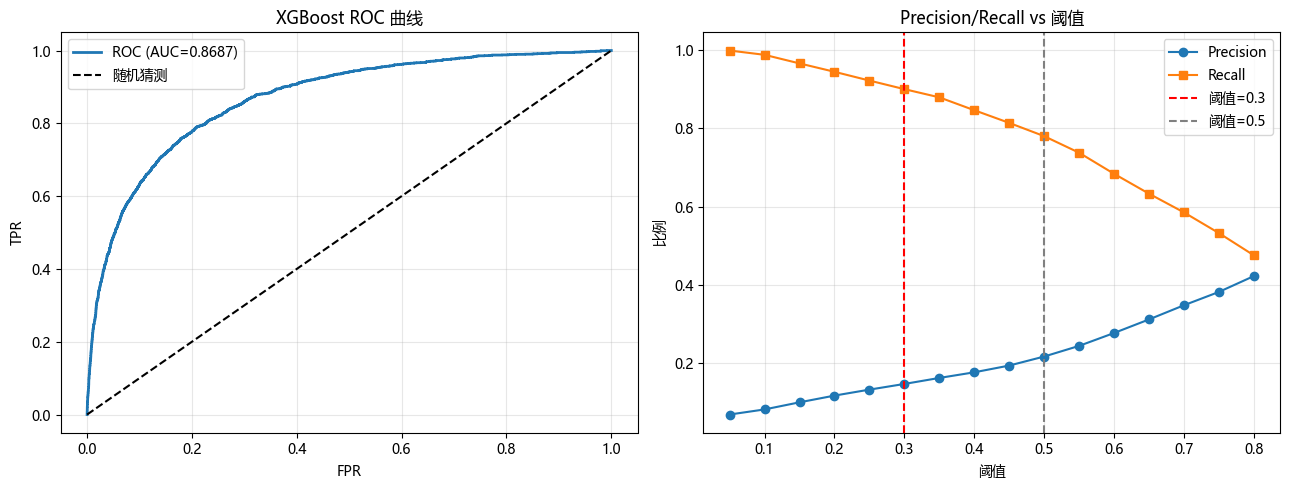

XGBoost 验证集 AUC: 0.8687
XGBoost 验证集 KS  : 0.5813


In [12]:
best_name = max(cv_results, key=cv_results.get)
best_model = results[best_name]["模型"]
y_val_proba_best = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.85, 0.05)
pr, rc = [], []
for t in thresholds:
    pred_t = (y_val_proba_best >= t).astype(int)
    pr.append(precision_score(y_val, pred_t, zero_division=0))
    rc.append(recall_score(y_val, pred_t))

fpr, tpr, _ = roc_curve(y_val, y_val_proba_best)
auc_score = roc_auc_score(y_val, y_val_proba_best)
ks = max(tpr - fpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, lw=2, label=f"ROC (AUC={auc_score:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", label="随机猜测")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title(f"{best_name} ROC 曲线")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, pr, "o-", label="Precision")
axes[1].plot(thresholds, rc, "s-", label="Recall")
axes[1].axvline(0.3, color="red", linestyle="--", label="阈值=0.3")
axes[1].axvline(0.5, color="gray", linestyle="--", label="阈值=0.5")
axes[1].set_xlabel("阈值"); axes[1].set_ylabel("比例")
axes[1].set_title("Precision/Recall vs 阈值")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{best_name} 验证集 AUC: {auc_score:.4f}")
print(f"{best_name} 验证集 KS  : {ks:.4f}")


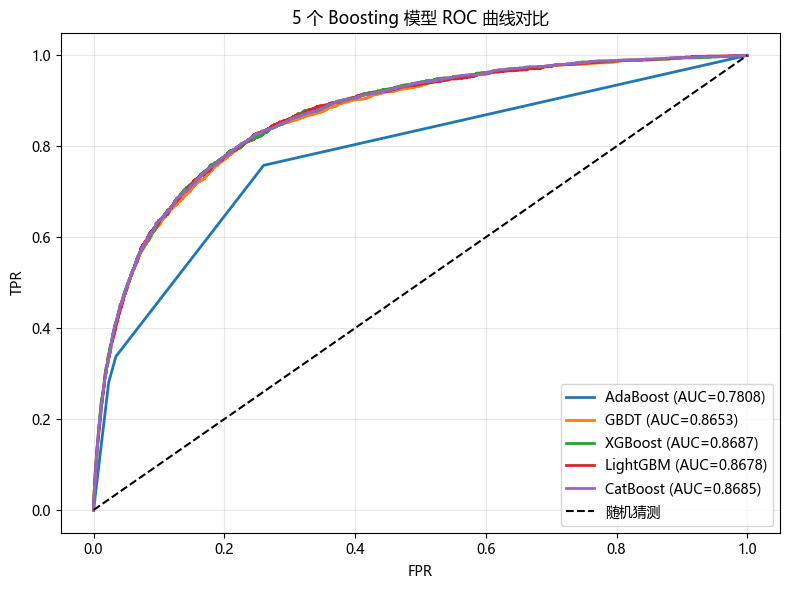

In [13]:
# ---- 全模型 ROC 曲线对比 ----
plt.figure(figsize=(8, 6))
for name in models:
    proba = results[name]["模型"].predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_val, proba):.4f})")
plt.plot([0, 1], [0, 1], "k--", label="随机猜测")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("5 个 Boosting 模型 ROC 曲线对比")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


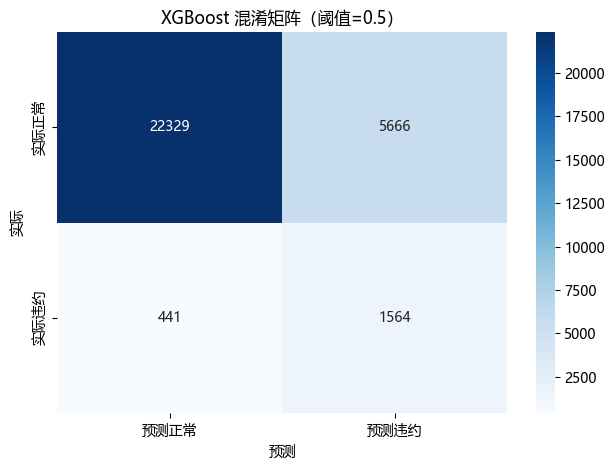

              precision    recall  f1-score   support

          正常       0.98      0.80      0.88     27995
          违约       0.22      0.78      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.84     30000



In [14]:
# ---- 最佳模型混淆矩阵（阈值 0.5） ----
y_pred_default = best_model.predict(X_val)
cm = confusion_matrix(y_val, y_pred_default)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["预测正常", "预测违约"],
            yticklabels=["实际正常", "实际违约"])
plt.title(f"{best_name} 混淆矩阵（阈值=0.5）")
plt.ylabel("实际"); plt.xlabel("预测")
plt.tight_layout()
plt.show()

print(classification_report(y_val, y_pred_default, target_names=["正常", "违约"]))


## 7. 特征重要性对比

树模型自带 `feature_importances_`，这里对比各个模型的 Top 特征。
**注意**：XGBoost / LightGBM / CatBoost 的重要性口径不同（gain / split / PredictionValuesChange），只能看趋势，不能跨模型比绝对值。


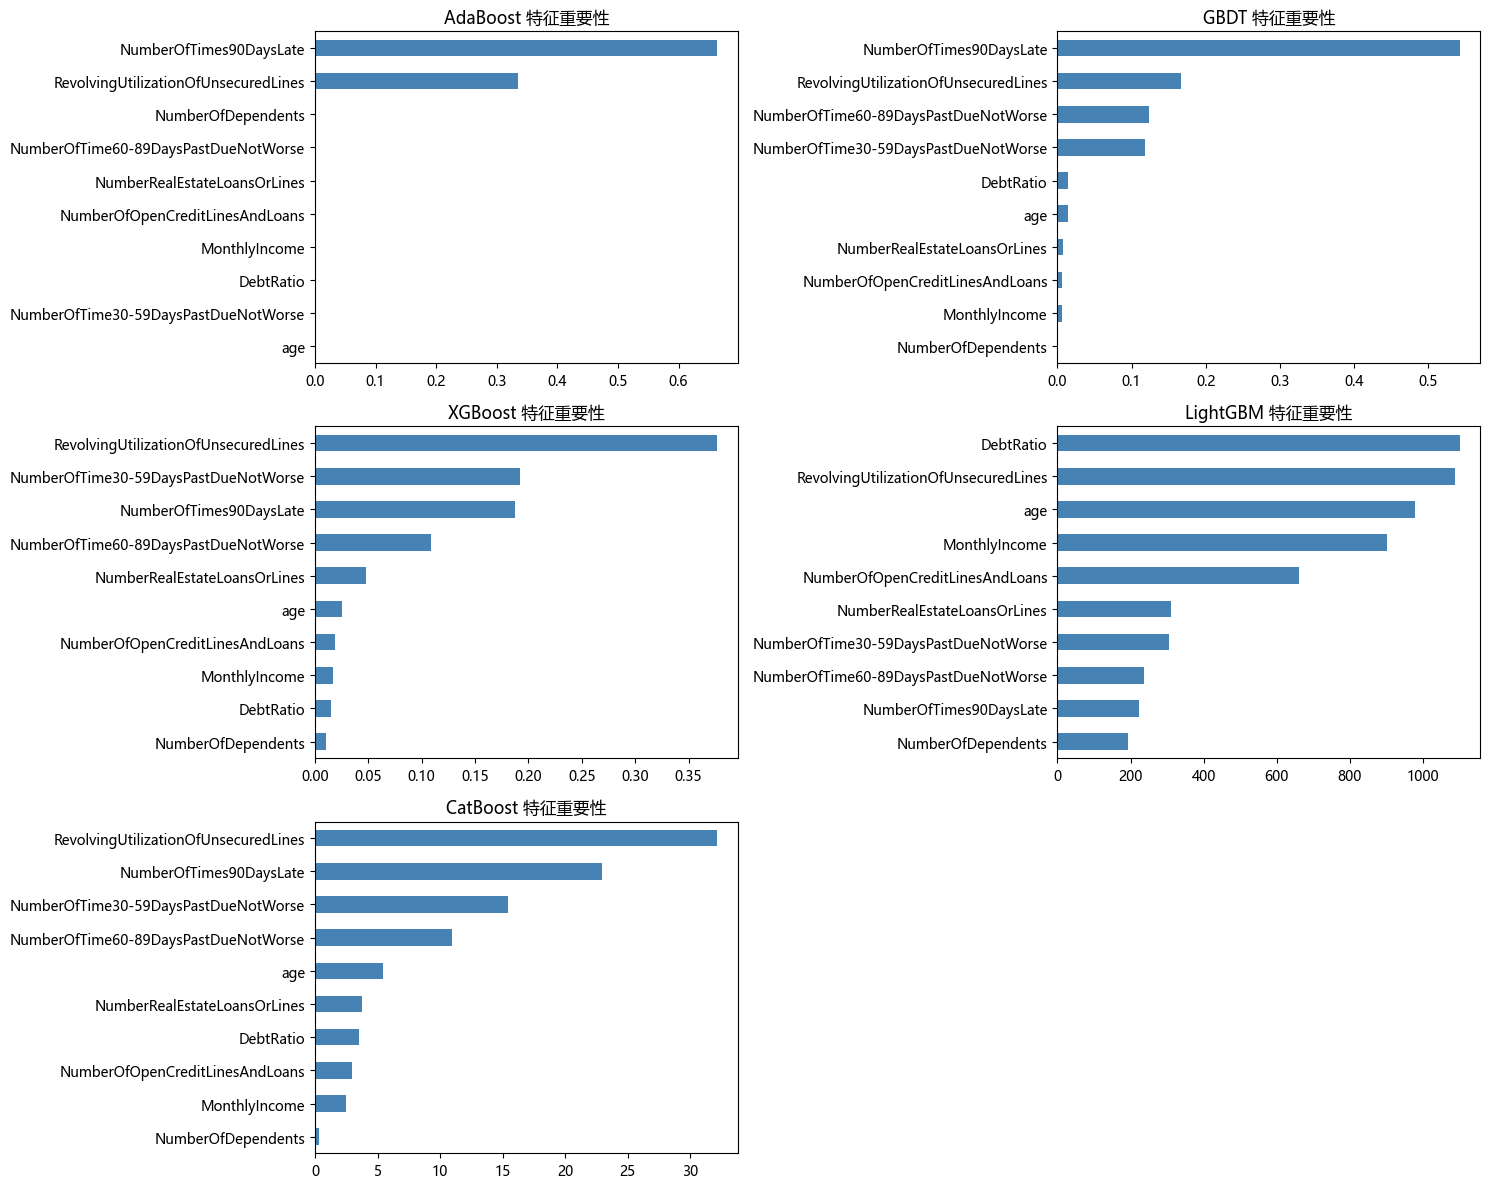

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, clf) in enumerate(models.items()):
    try:
        if name == "CatBoost":
            imp = clf.get_feature_importance()
        else:
            imp = clf.feature_importances_
        imp_series = pd.Series(imp, index=FEATURES).sort_values(ascending=True)
        imp_series.plot.barh(ax=axes[i], color="steelblue")
        axes[i].set_title(f"{name} 特征重要性")
    except Exception as e:
        axes[i].axis("off")
        axes[i].set_title(f"{name}: {type(e).__name__}")

for j in range(len(models), 6):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


## 8. 预测并生成提交文件


In [16]:
# ---- 用最佳模型预测测试集违约概率 ----
test_ids = sample[["Id"]]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "Id": test_ids["Id"].values,
    "Probability": y_test_proba,
})
submission.head()


,Id,Probability
0,1,0.5228
1,2,0.3885
2,3,0.1346
3,4,0.5276
4,5,0.6043


In [17]:
submission_path = os.path.join(DATA_DIR, "submission.csv")
submission.to_csv(submission_path, index=False)
print(f"已保存提交文件: {submission_path}")
print(f"提交行数: {len(submission)}（应与 sampleEntry 一致 = {len(sample)}）")


已保存提交文件: GMSC-data\submission.csv
提交行数: 101503（应与 sampleEntry 一致 = 101503）


In [18]:
print("=" * 60)
print("GMSC Boosting 家族项目完成！")
print("=" * 60)
print(f"  最佳模型      : {best_name}")
print(f"  5折CV-AUC     : {cv_results[best_name]:.4f}")
print(f"  验证集AUC     : {auc_score:.4f}")
print(f"  验证集KS      : {ks:.4f}")
print(f"  提交文件      : {submission_path}")
print("=" * 60)
print("\n演进结论：新一代 Boosting（XGBoost/LightGBM/CatBoost）通常优于老一代（AdaBoost/GBDT），在速度与准确性上都有工程级优化。")


GMSC Boosting 家族项目完成！
  最佳模型      : XGBoost
  5折CV-AUC     : 0.8656
  验证集AUC     : 0.8687
  验证集KS      : 0.5813
  提交文件      : GMSC-data\submission.csv

演进结论：新一代 Boosting（XGBoost/LightGBM/CatBoost）通常优于老一代（AdaBoost/GBDT），在速度与准确性上都有工程级优化。
